# 💰 Análise de Gastos Pessoais com pandas

Este notebook usa o mesmo banco (`gastos.db`) do playground SQL, mas resolve as
mesmas perguntas com **pandas**. Os testes em `tests/test_analysis.py` confirmam
que os resultados batem com as consultas SQL equivalentes.

In [1]:
import sys
sys.path.insert(0, '../analise')
import analysis as an

conn = an.conectar('../gastos.db')
df = an.carregar_transacoes(conn)
valor_hora = an.carregar_valor_hora(conn)
df.head()

id,data,descricao,valor,categoria,conta
13,2026-06-01,Supermercado,260.0,Alimentação,Nubank
1,2026-06-05,Netflix,39.9,Assinaturas,Nubank
2,2026-06-08,Academia,120.0,Saúde,Nubank
3,2026-06-12,Spotify,21.9,Assinaturas,Nubank
14,2026-06-15,Uber,22.0,Transporte,Nubank


## Total gasto por categoria

In [1]:
resultado = an.total_por_categoria(df)
resultado

categoria,total,transacoes
Alimentação,1413.85,6
Moradia,1345.00,2
Saúde,606.30,6
Lazer,267.00,3
Assinaturas,252.20,8
Educação,205.00,2
Transporte,160.50,3


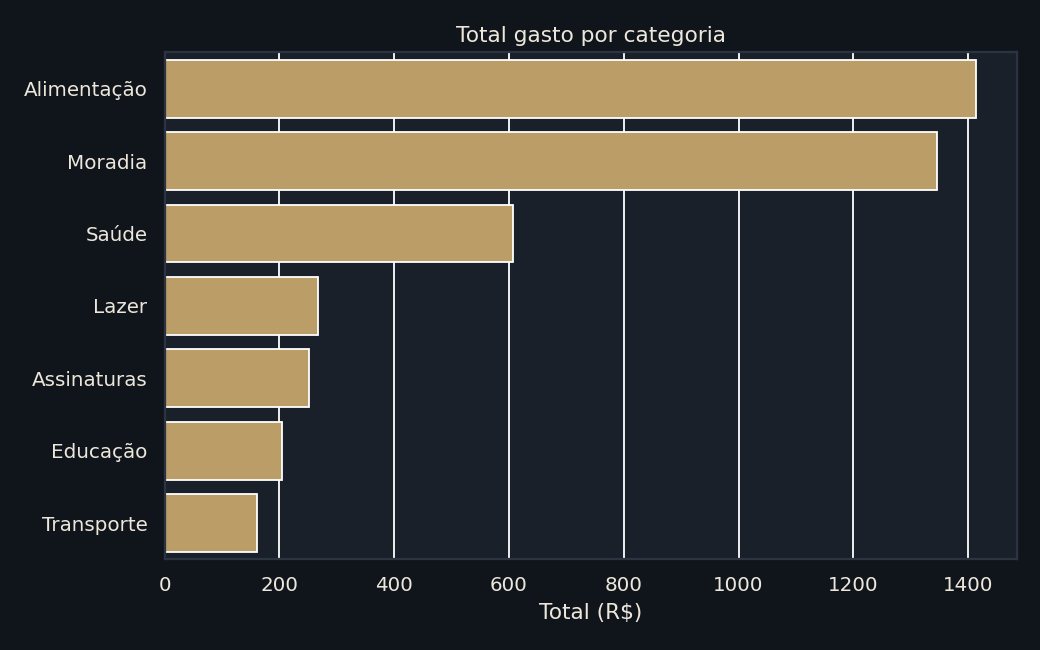

In [1]:
import sys; sys.path.insert(0, '../analise')
%matplotlib inline
import gerar_graficos
gerar_graficos.grafico_total_por_categoria(df)
from IPython.display import Image
Image('../analise/graficos/total_por_categoria.png')

## Ticket médio por categoria

In [1]:
an.ticket_medio_por_categoria(df)

categoria,ticket_medio
Moradia,672.50
Alimentação,235.64
Educação,102.50
Saúde,101.05
Lazer,89.00
Transporte,53.50
Assinaturas,31.52


## Gasto mensal (tendência)

In [1]:
an.gasto_mensal(df)

mes,total
2026-06-01,463.80
2026-07-01,494.10
2026-08-01,535.30
2026-09-01,2756.65


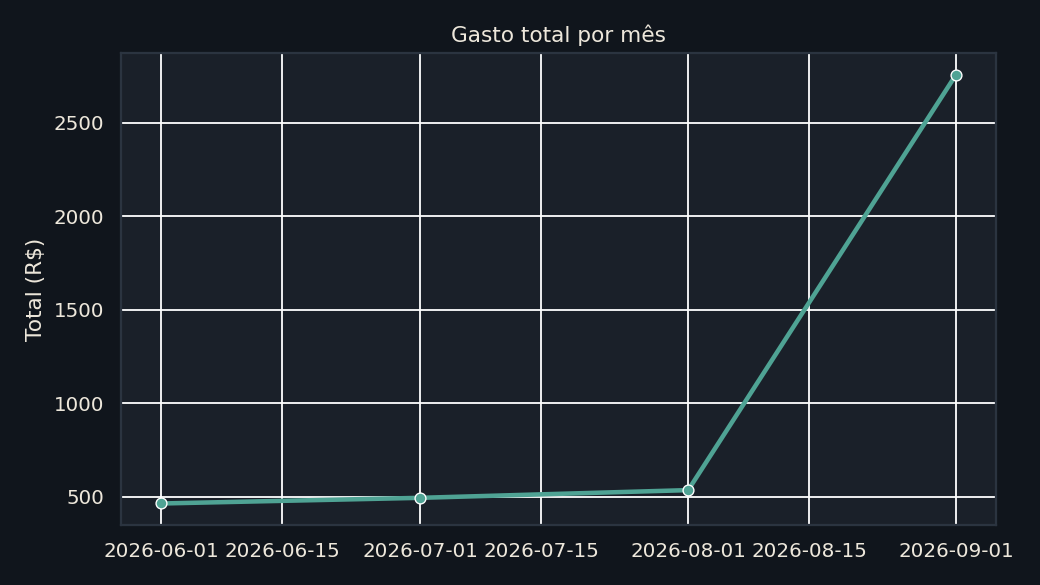

In [1]:
gerar_graficos.grafico_gasto_mensal(df)
Image('../analise/graficos/gasto_mensal.png')

## 🕒 Custo em horas de vida

Considerando R$ 45.00 por hora de trabalho:

In [1]:
an.custo_em_horas(df, valor_hora).head(10)[['descricao', 'valor', 'horas_trabalho']]

descricao,valor,horas_trabalho
Aluguel,1200.00,26.67
Supermercado,295.10,6.56
Supermercado,285.40,6.34
Supermercado,270.30,6.01
Supermercado,260.00,5.78
Mercado,210.75,4.68
Show de música,180.00,4.00
Curso online,150.00,3.33
Conta de luz,145.00,3.22
Academia,120.00,2.67


## 🔍 Detector de assinaturas esquecidas (pandas)

Reimplementação em pandas do detector que fizemos em SQL com window functions.
O teste `test_encontra_as_mesmas_assinaturas_que_o_sql` garante que os dois
caminhos chegam ao mesmo resultado.

In [1]:
an.detectar_assinaturas(df)

descricao,ocorrencias,intervalo_medio_dias,valor_medio_atual
Academia,4,30.7,120.00
Netflix,4,30.7,41.57
Spotify,4,30.7,21.90


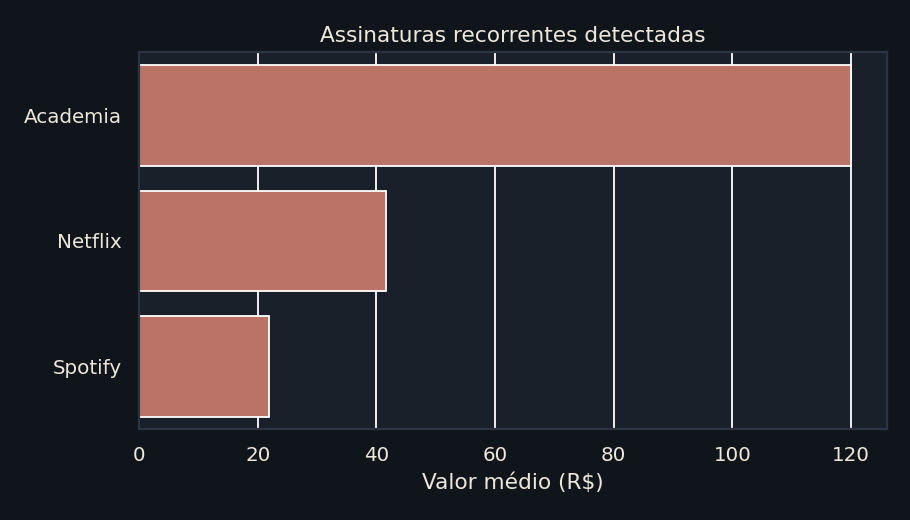

In [1]:
gerar_graficos.grafico_assinaturas(df)
Image('../analise/graficos/assinaturas.png')

## 📉 Projeção de saldo

Com base na média móvel de gasto diário dos últimos 30 dias, projeta quando
um saldo hipotético de R$ 3.000 se esgotaria no ritmo atual.

In [1]:
projecao = an.projecao_saldo(df, saldo_atual=3000, dias_futuros=30)
print(f"Média de gasto diário: R$ {projecao.attrs['media_diaria']}")
print(f"Dias até o saldo zerar, no ritmo atual: {projecao.attrs['dias_ate_zerar']}")
projecao.head(10)

Média de gasto diário: R$ 91.89
Dias até o saldo zerar, no ritmo atual: 33


dia,gasto_acumulado_projetado,saldo_projetado
1,91.89,2908.11
2,183.78,2816.22
3,275.67,2724.33
4,367.55,2632.45
5,459.44,2540.56
6,551.33,2448.67
7,643.22,2356.78
8,735.11,2264.89
9,827.00,2173.00
10,918.88,2081.12


## ✅ Conclusão

Todas as análises acima têm equivalente em SQL puro (veja `consultas.sql`) e
são validadas por testes automatizados em `tests/test_analysis.py`, que
comparam os resultados de pandas contra os do SQL diretamente.